In [11]:
# Imports as always...
import numpy as np
import pandas as pd
from tqdm.notebook import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
import torch.optim as optim

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.colors import Normalize

from datetime import datetime

import umap


import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [2]:
class SequenceDataset(Dataset):
    def __init__(self, df : pd.DataFrame, prior_length : int, qpu_filter : str | None = None):
        assert prior_length < df.step.max()
        
        # (Optionally) Filter devices.
        if qpu_filter:
            df = df[df['device'] == qpu_filter]
        
        # Order by completion time.
        df = df.sort_values(['device', 'completion_time']).reset_index(drop=True)
        
        # Encode device labels.
        qpus = sorted(df['device'].unique())
        self.qpu_label_encoding = {d : i for i, d in enumerate(qpus)}
        
        # Group by device.
        self.samples = []
        for qpu, group in df.groupby('device'):
            group = group.sort_values('completion_time')
            qpu_label = self.qpu_label_encoding[qpu]
            probs = group[list(filter(lambda x : x.startswith('x'), data_df.columns))].to_numpy(np.float32)
            
            # Normalise, just in case.
            probs /= probs.sum(axis=1, keepdims=True)
            
            # Sliding windows.
            for i in range(len(probs) - prior_length):
                self.samples.append((
                    probs[i : i + prior_length], # Prior.
                    probs[i + prior_length],     # Target.
                    qpu_label
                ))
                
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        xs, y, label = self.samples[idx]
        return (
            torch.tensor(xs, dtype=torch.float32),
            torch.tensor(y, dtype=torch.float32),
            torch.tensor(label, dtype=torch.long)
        )

In [36]:
# Read in data.
data_df = pd.read_csv('./data/time-varied/raw-data.csv')
display(data_df)

# PyTorch-ify.
dataset = SequenceDataset(data_df, prior_length=10, qpu_filter='Ankaa-3')
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

,index,n,step,batch,n_shots,device,task_id,completion_time,x00000,x00001,...,x10110,x10111,x11000,x11001,x11010,x11011,x11100,x11101,x11110,x11111
0,0,5,1,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,2025-08-06T01:41:30.594Z,0.410156,0.029297,...,0.010742,0.017578,0.004883,0.001953,0.001953,0.026367,0.007812,0.026367,0.015625,0.359375
1,1,5,2,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,2025-08-06T01:41:31.123Z,0.433594,0.019531,...,0.009766,0.021484,0.007812,0.004883,0.001953,0.027344,0.001953,0.021484,0.018555,0.328125
2,2,5,3,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,2025-08-06T01:41:32.032Z,0.420898,0.029297,...,0.011719,0.015625,0.000977,0.002930,0.002930,0.027344,0.000977,0.020508,0.019531,0.338867
3,3,5,4,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,2025-08-06T01:41:31.477Z,0.398438,0.017578,...,0.005859,0.023438,0.002930,0.004883,0.000977,0.033203,0.003906,0.028320,0.017578,0.367188
4,4,5,5,1,1024,Ankaa-3,arn:aws:braket:us-west-1:745438739765:quantum-...,2025-08-06T01:41:31.815Z,0.419922,0.023438,...,0.008789,0.018555,0.002930,0.002930,0.000977,0.022461,0.006836,0.025391,0.016602,0.342773
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
640,95,5,96,3,1024,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,2025-08-11T00:00:39.198Z,0.451172,0.025391,...,0.004883,0.011719,0.000000,0.000977,0.002930,0.010742,0.004883,0.037109,0.009766,0.381836
641,96,5,97,3,1024,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,2025-08-11T00:00:53.703Z,0.422852,0.012695,...,0.001953,0.014648,0.000977,0.003906,0.000977,0.018555,0.004883,0.037109,0.011719,0.418945
642,97,5,98,3,1024,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,2025-08-11T00:01:33.666Z,0.425781,0.012695,...,0.001953,0.009766,0.000000,0.002930,0.002930,0.021484,0.002930,0.050781,0.019531,0.387695
643,98,5,99,3,1024,Garnet,arn:aws:braket:eu-north-1:745438739765:quantum...,2025-08-11T00:01:10.201Z,0.482422,0.019531,...,0.000977,0.017578,0.000000,0.000977,0.003906,0.021484,0.000977,0.032227,0.007812,0.361328


In [48]:
class LSTM(nn.Module):
    def __init__(self, hidden_dim : int = 128, n_layers : int = 3, dropout : float = .5):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=32,
            hidden_size=hidden_dim,
            num_layers=n_layers,
            batch_first=True,
            dropout=dropout
        )
        
        self.fc = nn.Linear(hidden_dim, 32)
        
    def forward(self, x):
        out, _ = self.lstm(x)
        
        # Look at the last hidden state (the prediction)
        last = out[:, -1, :]
        
        # Fully-connected + softmax.
        logits = self.fc(last)
        return F.softmax(logits, dim=-1)

In [51]:
def train(model, loader, n_epochs=20, lr=1e-3):
    model.to(device)
    optimiser = optim.Adam(model.parameters(), lr=lr)
    
    for epoch in tqdm(range(1, n_epochs + 1)):
        model.train()
        total_loss = .0
        
        for x, y_true, _ in loader:
            x, y_true = x.to(device), y_true.to(device)

            optimiser.zero_grad()
            y_pred = model(x)
            
            # KL divergence (predicted vs. true distribution)
            loss = F.kl_div(y_pred.log(), y_true, reduction='batchmean')
            
            loss.backward()
            optimiser.step()
            
            total_loss += loss.item() * x.size(0)
        
        avg_loss = total_loss / len(loader.dataset)
        print(f'Epoch {epoch:02d} | Loss: {avg_loss:.6f}')
        
model = LSTM(128, 5, .75)
train(model, dataloader, n_epochs=100, lr=1e-4)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 01 | Loss: 1.739340
Epoch 02 | Loss: 1.674468
Epoch 03 | Loss: 1.517143
Epoch 04 | Loss: 0.837349
Epoch 05 | Loss: 0.147635
Epoch 06 | Loss: 0.066388
Epoch 07 | Loss: 0.043464
Epoch 08 | Loss: 0.034735
Epoch 09 | Loss: 0.030164
Epoch 10 | Loss: 0.027717
Epoch 11 | Loss: 0.026984
Epoch 12 | Loss: 0.026452
Epoch 13 | Loss: 0.025894
Epoch 14 | Loss: 0.025674
Epoch 15 | Loss: 0.025839
Epoch 16 | Loss: 0.025490
Epoch 17 | Loss: 0.025220
Epoch 18 | Loss: 0.025122
Epoch 19 | Loss: 0.025103
Epoch 20 | Loss: 0.025014
Epoch 21 | Loss: 0.025153
Epoch 22 | Loss: 0.024954
Epoch 23 | Loss: 0.025066
Epoch 24 | Loss: 0.024833
Epoch 25 | Loss: 0.024681
Epoch 26 | Loss: 0.024797
Epoch 27 | Loss: 0.024742
Epoch 28 | Loss: 0.024689
Epoch 29 | Loss: 0.024709
Epoch 30 | Loss: 0.024694
Epoch 31 | Loss: 0.024771
Epoch 32 | Loss: 0.024480
Epoch 33 | Loss: 0.024704
Epoch 34 | Loss: 0.024560
Epoch 35 | Loss: 0.024609
Epoch 36 | Loss: 0.024540
Epoch 37 | Loss: 0.024450
Epoch 38 | Loss: 0.024553
Epoch 39 | L

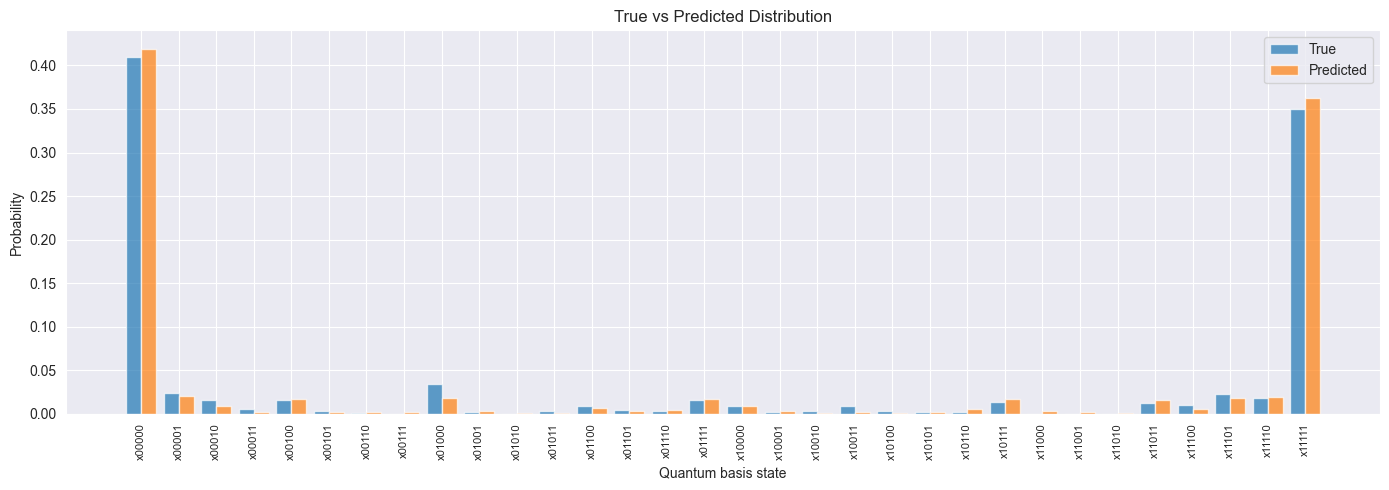

In [54]:
def plot_distribution_comparison(true_probs, pred_probs, state_labels=None, device_name=None):
    """
    Compare true vs. predicted probability distributions side-by-side.
    Both inputs can be tensors from any device.
    """
    # Ensure CPU numpy arrays
    if isinstance(true_probs, torch.Tensor):
        true_probs = true_probs.detach().cpu().numpy()
    if isinstance(pred_probs, torch.Tensor):
        pred_probs = pred_probs.detach().cpu().numpy()
    
    true_probs = np.clip(true_probs, 0, 1)
    pred_probs = np.clip(pred_probs, 0, 1)

    n_states = len(true_probs)
    x = np.arange(n_states)
    if state_labels is None:
        state_labels = [f"x{format(i, '05b')}" for i in range(n_states)]

    width = 0.4
    plt.figure(figsize=(14, 5))
    plt.bar(x - width/2, true_probs, width, label="True", alpha=0.7)
    plt.bar(x + width/2, pred_probs, width, label="Predicted", alpha=0.7)

    plt.xlabel("Quantum basis state")
    plt.ylabel("Probability")
    plt.title(f"True vs Predicted Distribution{f' ({device_name})' if device_name else ''}")
    plt.legend()

    plt.xticks(x, state_labels, rotation=90, fontsize=8)
    plt.tight_layout()
    plt.show()

# Evaluation / visualization
model.eval()
with torch.no_grad():
    for x, y, device_label in dataloader:
        x = x.to(device)
        y = y.to(device)
        pred = model(x)
        
        true_probs = y[1]
        pred_probs = pred[1]
        plot_distribution_comparison(true_probs, pred_probs)
        break

In [36]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

def plot_tsne_pred_vs_true(model, dataloader, n_samples=500, perplexity=30, random_state=42, device=None):
    """
    Visualize true vs. predicted probability distributions via t-SNE.
    
    Args:
        model: trained model
        dataloader: DataLoader yielding (x, y, label)
        n_samples: max number of (pred,true) pairs to visualize
        perplexity: t-SNE perplexity parameter
        random_state: for reproducibility
        device: torch.device (will default automatically)
    """
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.eval().to(device)

    preds, trues = [], []

    with torch.no_grad():
        for x, y, _ in dataloader:
            x = x.to(device)
            y = y.to(device)
            p = model(x)
            preds.append(p)
            trues.append(y)

            # Stop when enough samples collected
            if sum(len(batch) for batch in preds) * x.size(0) >= n_samples:
                break

    preds = torch.cat(preds, dim=0)[:n_samples]
    trues = torch.cat(trues, dim=0)[:n_samples]

    # Move to CPU numpy
    preds_np = preds.detach().cpu().numpy()
    trues_np = trues.detach().cpu().numpy()

    # Stack together for joint embedding
    data = np.vstack([trues_np, preds_np])
    labels = np.array(["True"] * len(trues_np) + ["Predicted"] * len(preds_np))

    # t-SNE
    tsne = TSNE(n_components=2, perplexity=perplexity, random_state=random_state, init='pca')
    emb = tsne.fit_transform(data)

    # Plot
    plt.figure(figsize=(8, 6))
    for label, color in zip(["True", "Predicted"], ["tab:blue", "tab:orange"]):
        idx = labels == label
        plt.scatter(emb[idx, 0], emb[idx, 1], s=20, alpha=0.7, label=label, color=color)

    plt.title("t-SNE of True vs Predicted Quantum Distributions")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.tight_layout()
    plt.show()

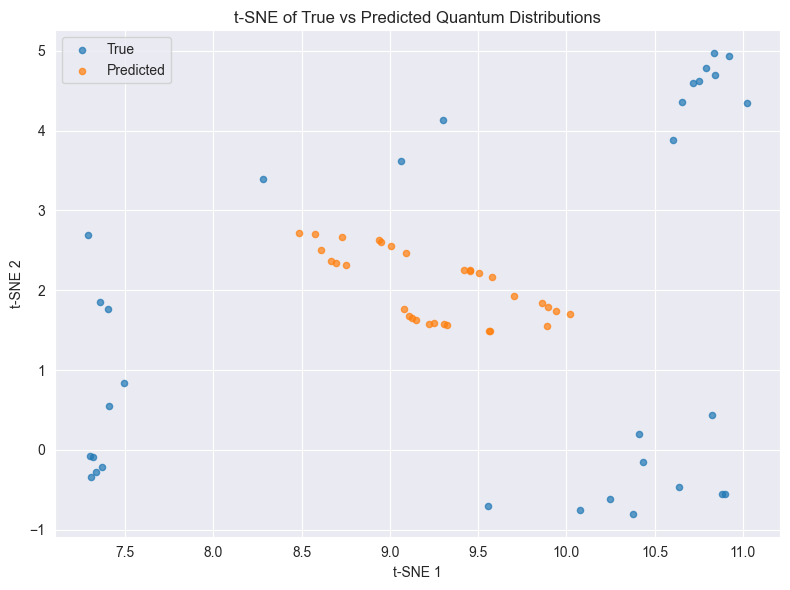

In [55]:
plot_tsne_pred_vs_true(model, dataloader, n_samples=500)

In [60]:
class TimeAwareSequenceDataset(Dataset):
    def __init__(self, df: pd.DataFrame, prior_length: int = 5):
        assert prior_length < df.step.max()
        
        self.prior_length = prior_length
        
        # Order by completion time.
        df = df.sort_values('completion_time').reset_index(drop=True)
        self.df = df.copy()
        
        # Note which columns are distribution columns.
        self.prob_columns = [c for c in df.columns if c.startswith('x')]

        # Times as numerics (seconds).
        self.df['timestamp'] = pd.to_datetime(self.df['completion_time']).astype(np.int64) / 1e9

        # Specify which indices have enough history to be sampled.
        self.valid_indices = list(range(prior_length, len(df)))

    def __len__(self):
        return len(self.valid_indices)

    def __getitem__(self, idx):
        target_idx = self.valid_indices[idx]
        past_idx = range(target_idx - self.prior_length, target_idx)
        
        # Slice rows.
        target_row = self.df.iloc[target_idx]
        past_rows = self.df.iloc[list(past_idx)]
        
        # Compute relative time offsets.
        relative_times = (past_rows['timestamp'].values - target_row['timestamp']).astype(np.float32)
        
        # Features and target.
        xs = np.hstack([relative_times[:, None], past_rows[self.prob_columns].to_numpy(np.float32)])
        y = target_row[self.prob_columns].to_numpy(np.float32)
        
        return torch.tensor(xs, dtype=torch.float32), torch.tensor(y, dtype=torch.float32)

In [61]:
class RelativeLSTM(nn.Module):
    def __init__(self, input_dim=33, hidden_dim=64, num_layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout,
        )
        self.fc = nn.Linear(hidden_dim, 32)

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        logits = self.fc(last)
        probs = F.softmax(logits, dim=-1)
        return probs

In [62]:
def train(model, loader, num_epochs=20, lr=1e-3):
    model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for epoch in tqdm(range(1, num_epochs + 1)):
        model.train()
        total_loss = 0.0

        for x, y in loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            pred = model(x)
            loss = F.kl_div(pred.log(), y, reduction="batchmean")
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * x.size(0)

        avg_loss = total_loss / len(dataloader.dataset)
        print(f"Epoch {epoch:02d} | Loss: {avg_loss:.6f}")

In [63]:
# Read in data.
data_df = pd.read_csv('./data/time-varied/raw-data.csv')
data_df = data_df[data_df['device'] == 'Ankaa-3']

# PyTorch-ify.
dataset = TimeAwareSequenceDataset(data_df, prior_length=5)
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)

In [64]:
model = RelativeLSTM(input_dim=33, hidden_dim=64)
train(model, dataloader, num_epochs=100)

  0%|          | 0/100 [00:00<?, ?it/s]

Epoch 01 | Loss: 1.490601
Epoch 02 | Loss: 0.325117
Epoch 03 | Loss: 0.049426
Epoch 04 | Loss: 0.028786
Epoch 05 | Loss: 0.025303
Epoch 06 | Loss: 0.024745
Epoch 07 | Loss: 0.024429
Epoch 08 | Loss: 0.024301
Epoch 09 | Loss: 0.024219
Epoch 10 | Loss: 0.024214
Epoch 11 | Loss: 0.024104
Epoch 12 | Loss: 0.023971
Epoch 13 | Loss: 0.023849
Epoch 14 | Loss: 0.023812
Epoch 15 | Loss: 0.023658
Epoch 16 | Loss: 0.023314
Epoch 17 | Loss: 0.023017
Epoch 18 | Loss: 0.022553
Epoch 19 | Loss: 0.021765
Epoch 20 | Loss: 0.021248
Epoch 21 | Loss: 0.020678
Epoch 22 | Loss: 0.020262
Epoch 23 | Loss: 0.020050
Epoch 24 | Loss: 0.019988
Epoch 25 | Loss: 0.019844
Epoch 26 | Loss: 0.019851
Epoch 27 | Loss: 0.019724
Epoch 28 | Loss: 0.019722
Epoch 29 | Loss: 0.019724
Epoch 30 | Loss: 0.019635
Epoch 31 | Loss: 0.019654
Epoch 32 | Loss: 0.019600
Epoch 33 | Loss: 0.019608
Epoch 34 | Loss: 0.019567
Epoch 35 | Loss: 0.019550
Epoch 36 | Loss: 0.019598
Epoch 37 | Loss: 0.019589
Epoch 38 | Loss: 0.019547
Epoch 39 | L

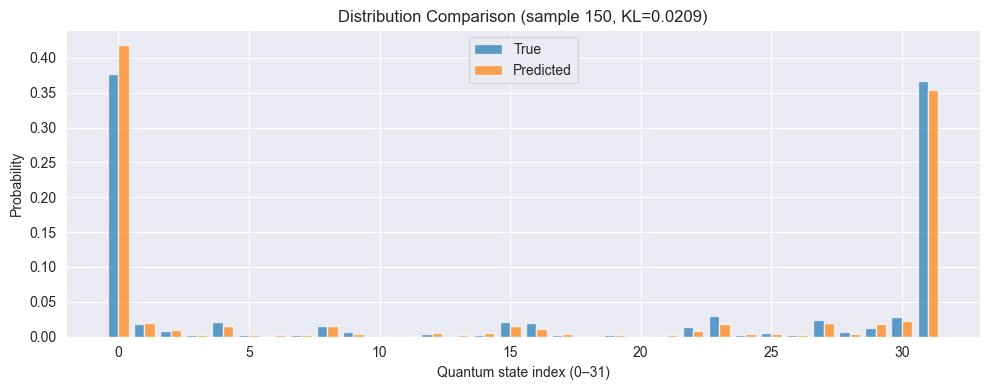

In [65]:
def plot_distribution_comparison(model, dataset, sample_idx, device=None, figsize=(10, 4)):
    # --- Device setup ---
    device = device or torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device).eval()

    # --- Fetch and move data ---
    x, y_true = dataset[sample_idx]
    x = x.unsqueeze(0).to(device)         # [1, seq_len, 33]
    y_true = y_true.unsqueeze(0).to(device)  # [1, 32]

    # --- Forward pass ---
    with torch.no_grad():
        y_pred = model(x)

    # --- Move to CPU for plotting ---
    y_true_np = y_true.squeeze(0).detach().cpu().numpy()
    y_pred_np = y_pred.squeeze(0).detach().cpu().numpy()

    # --- Compute divergence ---
    kl_div = np.sum(y_true_np * (np.log(y_true_np + 1e-12) - np.log(y_pred_np + 1e-12)))

    # --- Plot ---
    num_states = len(y_true_np)
    states = np.arange(num_states)

    plt.figure(figsize=figsize)
    bar_width = 0.4
    plt.bar(states - bar_width/2, y_true_np, width=bar_width, label="True", alpha=0.7)
    plt.bar(states + bar_width/2, y_pred_np, width=bar_width, label="Predicted", alpha=0.7)

    plt.title(f"Distribution Comparison (sample {sample_idx}, KL={kl_div:.4f})")
    plt.xlabel("Quantum state index (0–31)")
    plt.ylabel("Probability")
    plt.legend()
    plt.tight_layout()
    plt.show()
    
plot_distribution_comparison(model, dataset, sample_idx=150)

In [66]:
from sklearn.model_selection import train_test_split

data_df["completion_time"] = pd.to_datetime(data_df["completion_time"])
data_df = data_df.sort_values("completion_time").reset_index(drop=True)

time_split_ratio = 0.8
split_idx = int(len(data_df) * time_split_ratio)

df_train = data_df.iloc[:split_idx].reset_index(drop=True)
df_val = data_df.iloc[split_idx:].reset_index(drop=True)

seq_len = 5
train_dataset = TimeAwareSequenceDataset(df_train, seq_len)
val_dataset   = TimeAwareSequenceDataset(df_val, seq_len)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")

Train samples: 235
Val samples:   55


In [67]:
from IPython.display import clear_output

def train(
    model,
    train_dataset,
    val_dataset,
    num_epochs=50,
    batch_size=32,
    lr=1e-3,
    plot_every=1,
):
    """
    Train model with live plotting inside a Jupyter notebook.
    Updates the loss plot inline after each epoch.
    """
    # --- Device setup ---
    model = model.to(device)

    # --- DataLoaders ---
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    # --- Loss & optimizer ---
    criterion = nn.KLDivLoss(reduction="batchmean")
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # --- Stats ---
    train_losses, val_losses = [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_train_loss = 0.0

        for x, y_true in train_loader:
            x, y_true = x.to(device), y_true.to(device)
            optimizer.zero_grad()
            y_pred = model(x)
            loss = criterion(torch.log(y_pred + 1e-12), y_true)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item() * x.size(0)

        avg_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(avg_train_loss)

        # --- Validation ---
        model.eval()
        running_val_loss = 0.0
        with torch.no_grad():
            for x, y_true in val_loader:
                x, y_true = x.to(device), y_true.to(device)
                y_pred = model(x)
                loss = criterion(torch.log(y_pred + 1e-12), y_true)
                running_val_loss += loss.item() * x.size(0)

        avg_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(avg_val_loss)

        # --- Print progress ---
        print(f"Epoch [{epoch}/{num_epochs}] "
              f"Train Loss: {avg_train_loss:.6f} | Val Loss: {avg_val_loss:.6f}")

        # --- Inline plot update ---
        if epoch % plot_every == 0:
            clear_output(wait=True)
            plt.figure(figsize=(7, 4))
            plt.plot(train_losses, label="Train", color="blue")
            plt.plot(val_losses, label="Validation", color="orange")
            plt.yscale('log')
            plt.xlabel("Epoch")
            plt.ylabel("KLDiv Loss")
            plt.title("Training and Validation Loss")
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.4)
            plt.tight_layout()
            plt.show()

    return {"train_losses": train_losses, "val_losses": val_losses}

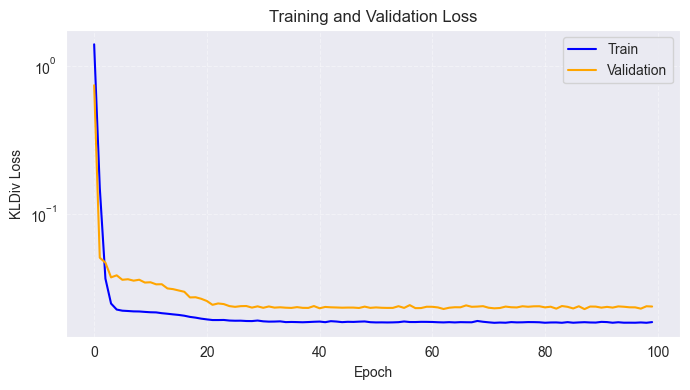

In [68]:
model = RelativeLSTM(input_dim=33, hidden_dim=128)
stats = train(
    model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    num_epochs=100,
    batch_size=16,
    lr=1e-3,
    plot_every=5,
)

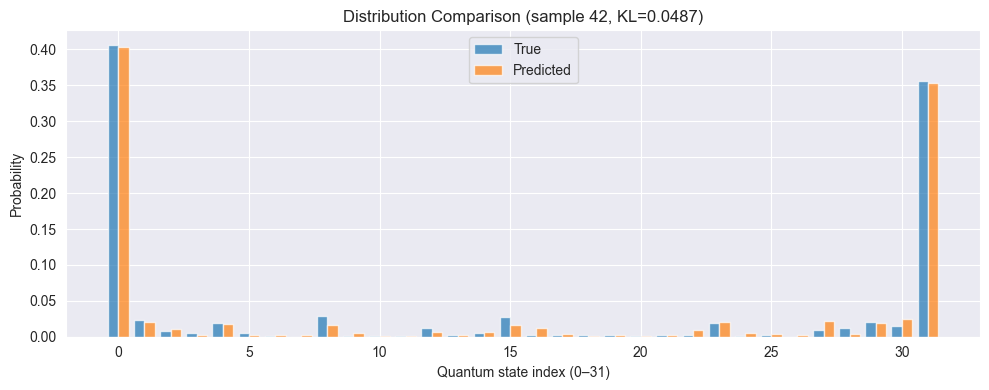

In [69]:
plot_distribution_comparison(model, val_dataset, sample_idx=42)

In [70]:
def plot_tsne_predictions_vs_true(
    model,
    val_dataset,
    perplexity=30,
    n_samples=500,
    connect_pairs=True,
    min_alpha=0.1,
):
    """
    Projects true and predicted probability distributions from the validation set
    into 2D using t-SNE, and visualizes them in a scatter plot.

    Connection line opacity encodes inverse KL divergence:
      - Opaque (alpha ≈ 1): low error (accurate)
      - Transparent (alpha ≈ min_alpha): high error (inaccurate)
    
    Uses global `device` variable defined in the notebook.
    """
    global device
    model = model.to(device).eval()

    # --- Sample subset of validation data ---
    n_samples = min(n_samples, len(val_dataset))
    indices = np.linspace(0, len(val_dataset) - 1, n_samples, dtype=int)

    preds, trues, errors = [], [], []

    with torch.no_grad():
        for idx in indices:
            x, y_true = val_dataset[idx]
            x = x.unsqueeze(0).to(device)
            y_pred = model(x).squeeze(0).cpu().numpy()
            y_true_np = y_true.numpy()

            preds.append(y_pred)
            trues.append(y_true_np)

            # Compute KL divergence
            kl = np.sum(y_true_np * (np.log(y_true_np + 1e-12) - np.log(y_pred + 1e-12)))
            errors.append(kl)

    preds = np.stack(preds)
    trues = np.stack(trues)
    errors = np.array(errors)

    # --- Normalize error to alpha in [min_alpha, 1] ---
    err_min, err_max = np.percentile(errors, [5, 95])  # robust normalization
    normed = np.clip((errors - err_min) / (err_max - err_min + 1e-12), 0, 1)
    alphas = 1.0 - (1.0 - min_alpha) * normed  # ensures min alpha = min_alpha

    # --- Combine for t-SNE ---
    X = np.concatenate([trues, preds], axis=0)
    print("Running t-SNE dimensionality reduction...")
    tsne = TSNE(
        n_components=2,
        perplexity=perplexity,
        learning_rate="auto",
        init="random",
        random_state=42,
    )
    X_embedded = tsne.fit_transform(X)

    # --- Split for plotting ---
    X_true = X_embedded[:len(trues)]
    X_pred = X_embedded[len(trues):]

    # --- Plot ---
    clear_output(wait=True)
    plt.figure(figsize=(8, 6))

    if connect_pairs:
        for i in range(len(trues)):
            plt.plot(
                [X_true[i, 0], X_pred[i, 0]],
                [X_true[i, 1], X_pred[i, 1]],
                color="gray",
                alpha=alphas[i],
                linewidth=0.8,
            )

    plt.scatter(X_true[:, 0], X_true[:, 1], c="blue", alpha=0.6, label="True", s=20)
    plt.scatter(X_pred[:, 0], X_pred[:, 1], c="orange", alpha=0.6, label="Predicted", s=20)

    plt.title("t-SNE Projection of True vs Predicted Distributions (Validation Set)")
    plt.xlabel("t-SNE 1")
    plt.ylabel("t-SNE 2")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    # Optional: print summary stats
    print(f"Mean KL divergence: {errors.mean():.4f}  |  Median: {np.median(errors):.4f}")


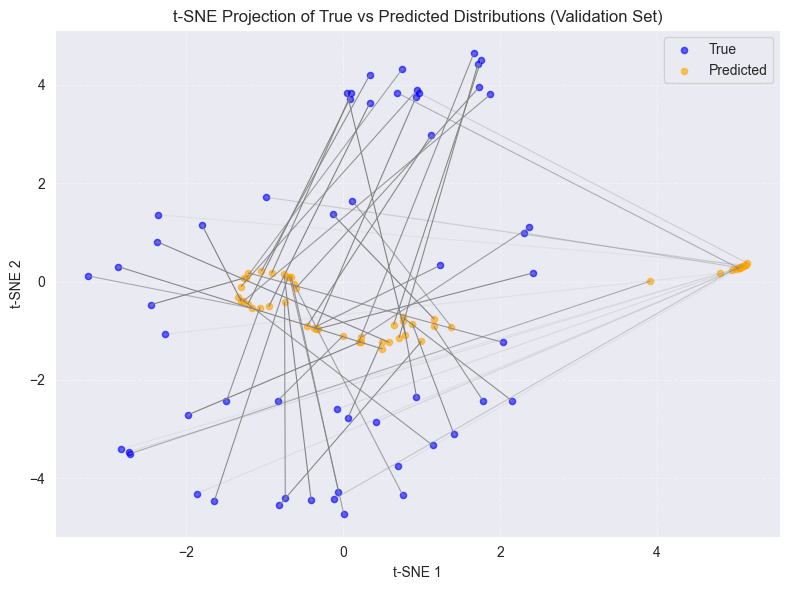

Mean KL divergence: 0.0238  |  Median: 0.0185


In [71]:
plot_tsne_predictions_vs_true(
    model,
    val_dataset,
    perplexity=35,
    n_samples=400,
    connect_pairs=True
)

In [72]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from IPython.display import clear_output

def plot_pca_predictions_vs_true(
    model,
    val_dataset,
    n_samples=500,
    connect_pairs=True,
    min_alpha=0.1,
):
    """
    Projects true and predicted probability distributions from the validation set
    into 2D using PCA, and visualizes them in a scatter plot.

    Connection line opacity encodes inverse KL divergence:
      - Opaque (alpha ≈ 1): low error (accurate)
      - Transparent (alpha ≈ min_alpha): high error (inaccurate)

    Uses the global `device` variable defined in the notebook.
    """
    global device
    model = model.to(device).eval()

    # --- Sample subset of validation data ---
    n_samples = min(n_samples, len(val_dataset))
    indices = np.linspace(0, len(val_dataset) - 1, n_samples, dtype=int)

    preds, trues, errors = [], [], []

    with torch.no_grad():
        for idx in indices:
            x, y_true = val_dataset[idx]
            x = x.unsqueeze(0).to(device)
            y_pred = model(x).squeeze(0).cpu().numpy()
            y_true_np = y_true.numpy()

            preds.append(y_pred)
            trues.append(y_true_np)

            # Compute KL divergence for error weighting
            kl = np.sum(y_true_np * (np.log(y_true_np + 1e-12) - np.log(y_pred + 1e-12)))
            errors.append(kl)

    preds = np.stack(preds)
    trues = np.stack(trues)
    errors = np.array(errors)

    # --- Normalize error to alpha in [min_alpha, 1] ---
    err_min, err_max = np.percentile(errors, [5, 95])  # robust normalization
    normed = np.clip((errors - err_min) / (err_max - err_min + 1e-12), 0, 1)
    alphas = 1.0 - (1.0 - min_alpha) * normed  # ensures min alpha floor

    # --- Combine for PCA ---
    X = np.concatenate([trues, preds], axis=0)
    print("Running PCA dimensionality reduction...")
    pca = PCA(n_components=2, random_state=42)
    X_embedded = pca.fit_transform(X)

    # --- Split for plotting ---
    X_true = X_embedded[:len(trues)]
    X_pred = X_embedded[len(trues):]

    # --- Plot ---
    clear_output(wait=True)
    plt.figure(figsize=(8, 6))

    if connect_pairs:
        for i in range(len(trues)):
            plt.plot(
                [X_true[i, 0], X_pred[i, 0]],
                [X_true[i, 1], X_pred[i, 1]],
                color="gray",
                alpha=alphas[i],
                linewidth=0.8,
            )

    plt.scatter(X_true[:, 0], X_true[:, 1], c="blue", alpha=0.6, label="True", s=20)
    plt.scatter(X_pred[:, 0], X_pred[:, 1], c="orange", alpha=0.6, label="Predicted", s=20)

    plt.title("PCA Projection of True vs Predicted Distributions (Validation Set)")
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.tight_layout()
    plt.show()

    print(f"Mean KL divergence: {errors.mean():.4f}  |  Median: {np.median(errors):.4f}")


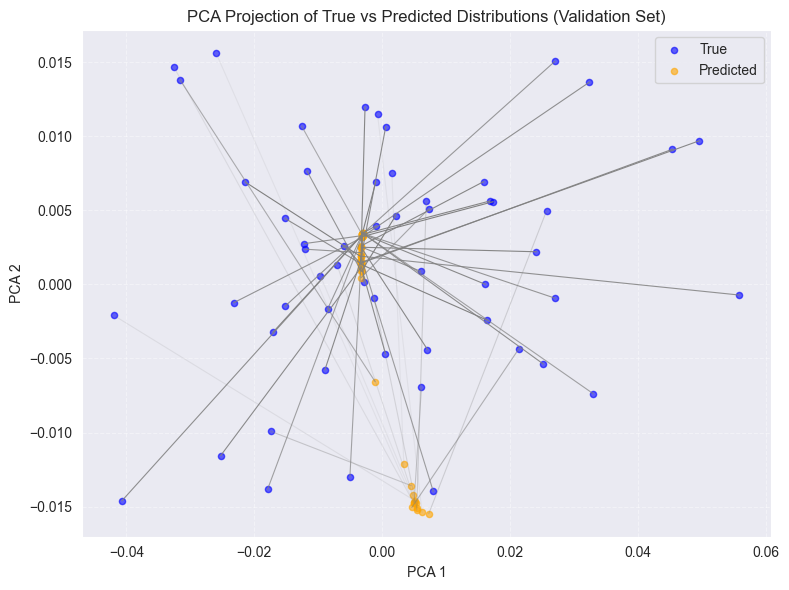

Mean KL divergence: 0.0238  |  Median: 0.0185


In [73]:
plot_pca_predictions_vs_true(
    model,
    val_dataset,
    n_samples=400,
    connect_pairs=True,
    min_alpha=0.1,
)


In [85]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def evaluate_fixed_input_forecast(df, model, n_input=5, plot=True):
    """
    Evaluate how forecast accuracy decays over time when predicting future distributions
    from a fixed initial sequence of n_input distributions.

    Args:
        df: DataFrame for one device with:
            - 'completion time' or 'completion_time'
            - probability columns (x00000...x11111)
        model: trained PyTorch model
        n_input: number of input distributions to fix as the model input
    Returns:
        DataFrame with columns ['relative_time', 'kl_loss']
    """
    model.eval()

    # --- pick correct time column ---
    tcol = 'completion_time'

    # --- detect probability columns ---
    prob_cols = [c for c in df.columns if str(c).startswith("x")]

    # --- sort by time ---
    df_sorted = df.sort_values(tcol).reset_index(drop=True)
    times = pd.to_datetime(df_sorted[tcol]).astype(np.int64).to_numpy() / 1e9  # seconds
    probs = df_sorted[prob_cols].to_numpy(dtype=np.float32)
    probs = probs / (probs.sum(axis=1, keepdims=True) + 1e-12)

    if len(probs) <= n_input:
        raise ValueError(f"Not enough data points to forecast beyond n_input={n_input}")

    # --- fixed input sequence ---
    base_probs = probs[:n_input]
    base_times = times[:n_input]
    t_ref = base_times[-1]
    rel_times = (base_times - t_ref).astype(np.float32).reshape(n_input, 1)
    fixed_input = np.hstack([rel_times, base_probs])  # shape [n_input, 33]

    x_input = torch.tensor(fixed_input, dtype=torch.float32, device=device).unsqueeze(0)

    # --- evaluate forecasts ---
    relative_times = []
    kl_losses = []

    with torch.no_grad():
        for j in range(n_input, len(probs)):
            y_true = torch.tensor(probs[j], dtype=torch.float32, device=device)
            y_true = torch.clamp(y_true, 1e-12, 1.0)
            y_true = y_true / y_true.sum()

            # forward pass (same fixed input every time)
            y_pred = model(x_input).squeeze(0)
            y_pred = torch.clamp(y_pred, 1e-12, 1.0)
            y_pred = y_pred / y_pred.sum()

            # compute KL divergence
            kl = torch.sum(y_true * (torch.log(y_true) - torch.log(y_pred))).item()

            relative_time = float(times[j] - t_ref)
            relative_times.append(relative_time)
            kl_losses.append(kl)

    # --- results DataFrame ---
    results = pd.DataFrame({
        "relative_time_sec": relative_times,
        "kl_loss": kl_losses
    })

    # --- plot ---
    if plot:
        plt.figure(figsize=(8, 5))
        plt.plot(results["relative_time_sec"], results["kl_loss"], marker="o")
        plt.xlabel("Time offset from last input (seconds)")
        plt.ylabel("KL Divergence (Predicted vs True)")
        plt.title(f"Forecast decay over time (fixed input, n_input={n_input})")
        plt.grid(True, linestyle="--", alpha=0.4)
        plt.tight_layout()
        plt.show()

    return results

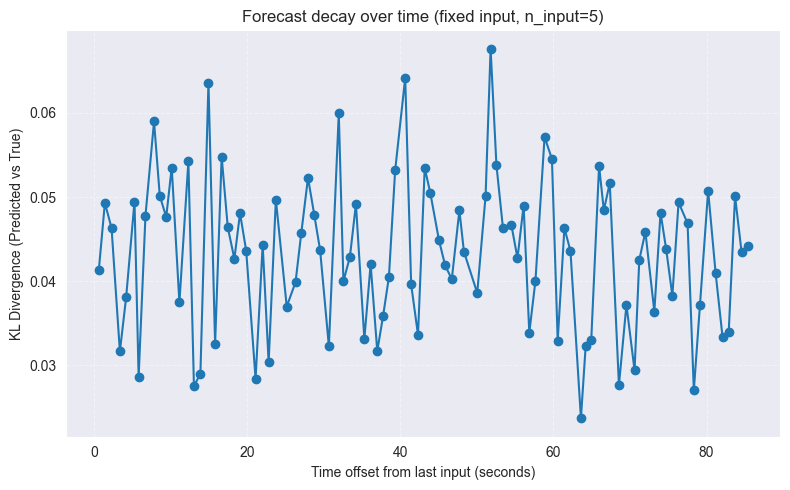

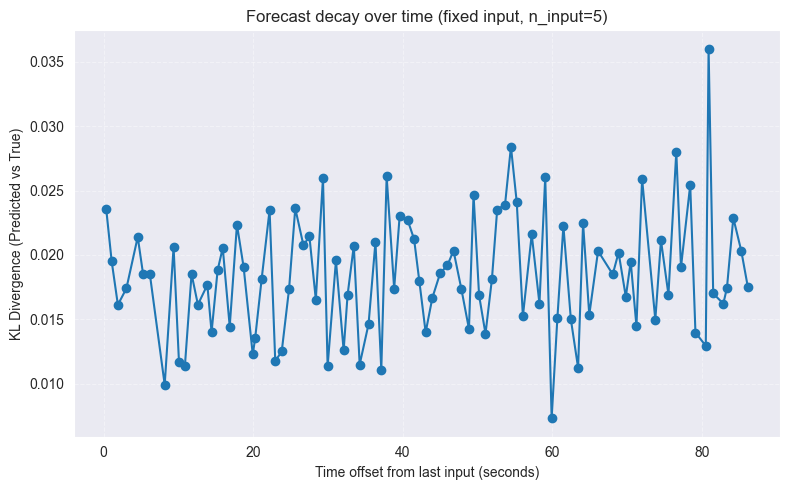

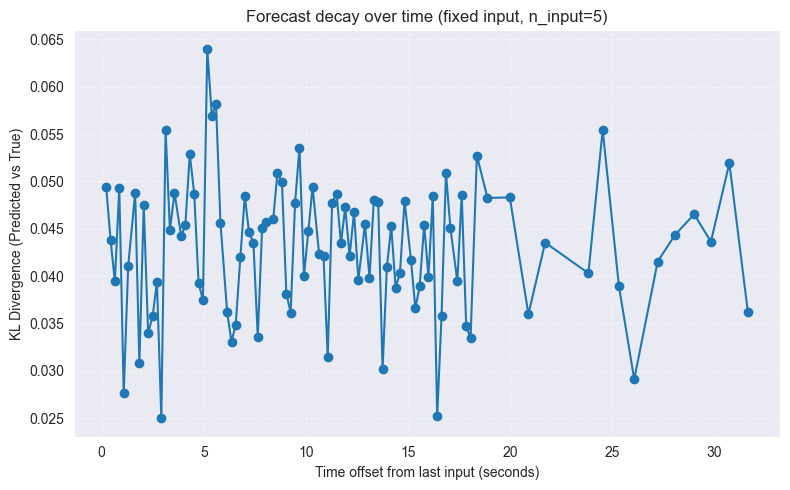

In [83]:
results_1 = evaluate_fixed_input_forecast(data_df[data_df['batch'] == 1], model, n_input=5)
results_2 = evaluate_fixed_input_forecast(data_df[data_df['batch'] == 2], model, n_input=5)
results_3 = evaluate_fixed_input_forecast(data_df[data_df['batch'] == 3], model, n_input=5)

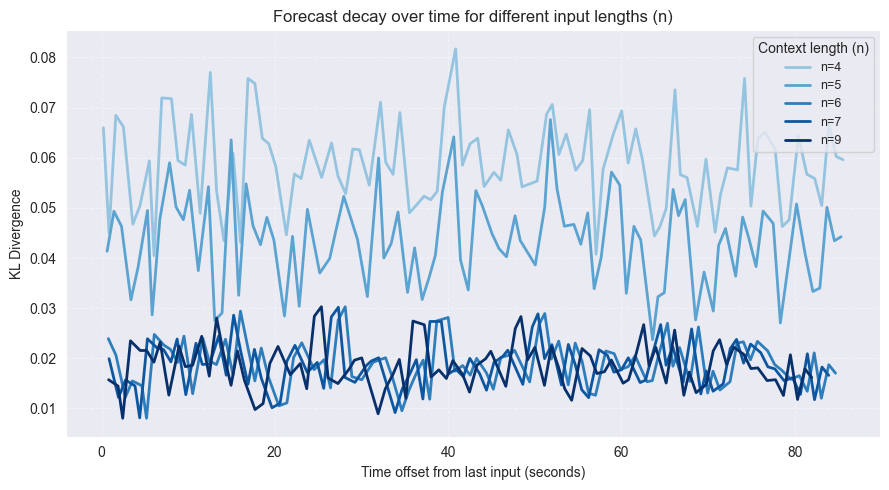

In [113]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import pandas as pd

def compare_forecast_horizons(df, model, n_values=[3, 5, 7, 9]):
    """
    Compare how forecast loss over time varies for different input sequence lengths n.
    Produces one plot showing multiple curves (darker blue = longer n).

    Args:
        df: single-device DataFrame with completion time + probability columns.
        model: trained PyTorch model.
        n_values: list of input sequence lengths to evaluate.
    Returns:
        dict of results {n: results_df}
    """
    results_dict = {}
    colors = cm.Blues(np.linspace(0.4, 1, len(n_values)))  # light → dark blue
    
    plt.figure(figsize=(9, 5))
    
    for color, n in zip(colors, n_values):
        try:
            res = evaluate_fixed_input_forecast(df, model, n_input=n, plot=False)
            results_dict[n] = res

            # Plot
            plt.plot(
                res["relative_time_sec"],
                res["kl_loss"],
                label=f"n={n}",
                color=color,
                linewidth=2,
            )
        except Exception as e:
            print(f"⚠️ Skipping n={n}: {e}")

    plt.xlabel("Time offset from last input (seconds)")
    plt.ylabel("KL Divergence")
    plt.title("Forecast decay over time for different input lengths (n)")
    plt.grid(True, linestyle="--", alpha=0.4)
    plt.legend(title="Context length (n)", fontsize=9)
    plt.tight_layout()
    plt.show()

    return results_dict

results_multi_n = compare_forecast_horizons(data_df[data_df['batch'] == 1], model, n_values=[
    4, 5, 6, 7, 9
])

In [116]:
results_dict = {}
for n in tqdm(range(1, 51)):
    res = evaluate_fixed_input_forecast(data_df, model, n_input=n, plot=False)['kl_loss'].mean()
    results_dict[n] = res

  0%|          | 0/50 [00:00<?, ?it/s]

(0.0, 0.3)

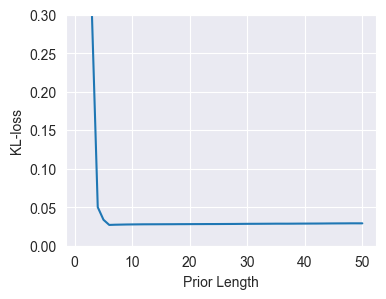

In [119]:
plt.figure(figsize=(4, 3))
plt.plot(list(results_dict.keys()), list(results_dict.values()))
plt.ylabel('KL-loss')
plt.xlabel('Prior Length')
plt.ylim(.0, .3)

In [120]:
results_dict

{1: 1.4873767058586198,
 2: 0.96746473544396,
 3: 0.29768721408113485,
 4: 0.05009380590195793,
 5: 0.03369923313227245,
 6: 0.027001676589985486,
 7: 0.027269955336691576,
 8: 0.0274167527661544,
 9: 0.02757565555549979,
 10: 0.02766236602007572,
 11: 0.027738824675252797,
 12: 0.027814647798853304,
 13: 0.02783784061631363,
 14: 0.027864827523724392,
 15: 0.02788870643595593,
 16: 0.02792073009391381,
 17: 0.027939227977339772,
 18: 0.02799481545997691,
 19: 0.028016784283070695,
 20: 0.028051948346131082,
 21: 0.028087022547413156,
 22: 0.028101434035012297,
 23: 0.028144108215582286,
 24: 0.028145574956147026,
 25: 0.028172886473211374,
 26: 0.02822280540063053,
 27: 0.028248159090336754,
 28: 0.028295198792714953,
 29: 0.028365091963695205,
 30: 0.028429446681575092,
 31: 0.02846487196937868,
 32: 0.028487735235048876,
 33: 0.028533047511615558,
 34: 0.028568434030083672,
 35: 0.028622485871233467,
 36: 0.028622277389689716,
 37: 0.02861432564186336,
 38: 0.02866084457780341,
 39:

# Temporal Drift

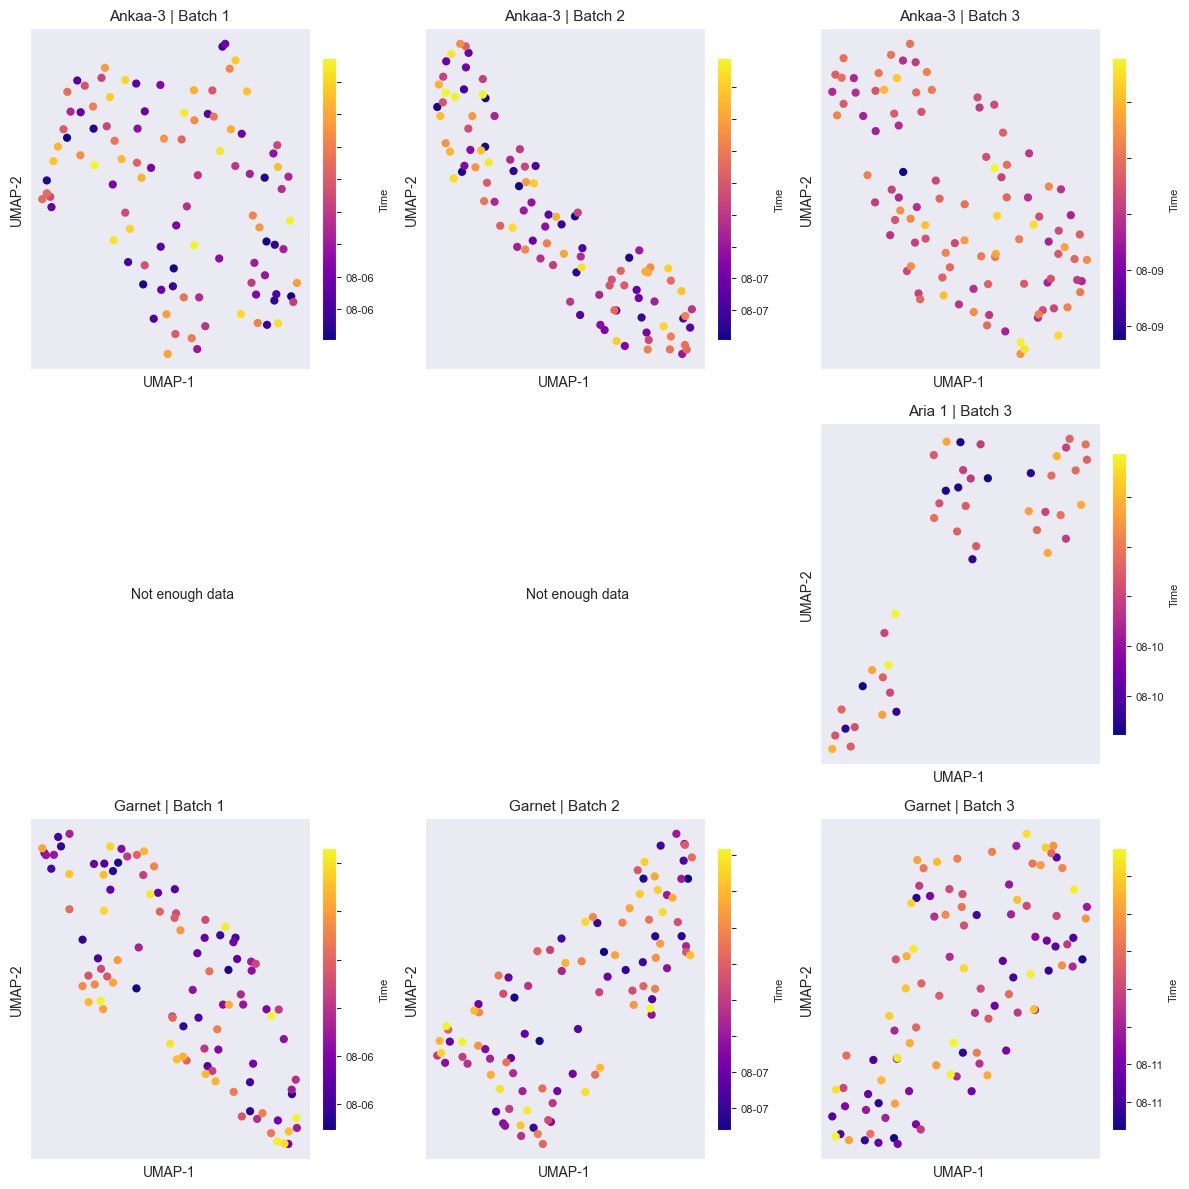

In [37]:
# Ensure datetime is parsed and sorted
data_df['completion_time'] = pd.to_datetime(data_df['completion_time'])
data_df = data_df.sort_values('completion_time')

# Identify columns
prob_cols = [c for c in data_df.columns if c.startswith('x')]
devices = sorted(data_df['device'].unique())
batches = sorted(data_df['batch'].unique())

# Define colormap (two-color gradient)
cmap = colormaps.get_cmap('plasma')  # try 'coolwarm' or 'cividis' if you prefer

# --- UMAP 3×3 Grid ---
fig, axes = plt.subplots(len(devices), len(batches), figsize=(12, 12))

for i, device in enumerate(devices):
    for j, batch in enumerate(batches):
        ax = axes[i, j]
        subset = data_df[(data_df['device'] == device) & (data_df['batch'] == batch)]
        
        if len(subset) < 2:
            ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center', fontsize=10)
            ax.set_axis_off()
            continue
        
        # Compute local time normalization (for that subset only)
        min_t = subset['completion_time'].min()
        max_t = subset['completion_time'].max()
        subset['time_norm_local'] = (subset['completion_time'] - min_t) / (max_t - min_t + pd.Timedelta('1ns'))
        
        reducer = umap.UMAP(random_state=42)
        embedding = reducer.fit_transform(subset[prob_cols])
        
        colors = cmap(subset['time_norm_local'].to_numpy())
        ax.scatter(embedding[:, 0], embedding[:, 1], c=colors, s=35, edgecolor='none')
        
        ax.set_title(f'{device} | Batch {batch}', fontsize=11)
        ax.set_xlabel('UMAP-1')
        ax.set_ylabel('UMAP-2')
        ax.set_xticks([])
        ax.set_yticks([])
        
        # Small inset colorbar for this subplot
        norm_local = Normalize(vmin=min_t.value, vmax=max_t.value)
        sm = plt.cm.ScalarMappable(norm=norm_local, cmap=cmap)
        sm.set_array([])
        cbar = fig.colorbar(sm, ax=ax, fraction=0.046, pad=0.04)
        cbar.ax.tick_params(labelsize=8)
        cbar.ax.set_yticklabels([
            datetime.utcfromtimestamp(t/1e9).strftime('%m-%d')
            for t in np.linspace(min_t.value, max_t.value, 3)
        ])
        cbar.set_label('Time', fontsize=8)

plt.tight_layout()
plt.show()


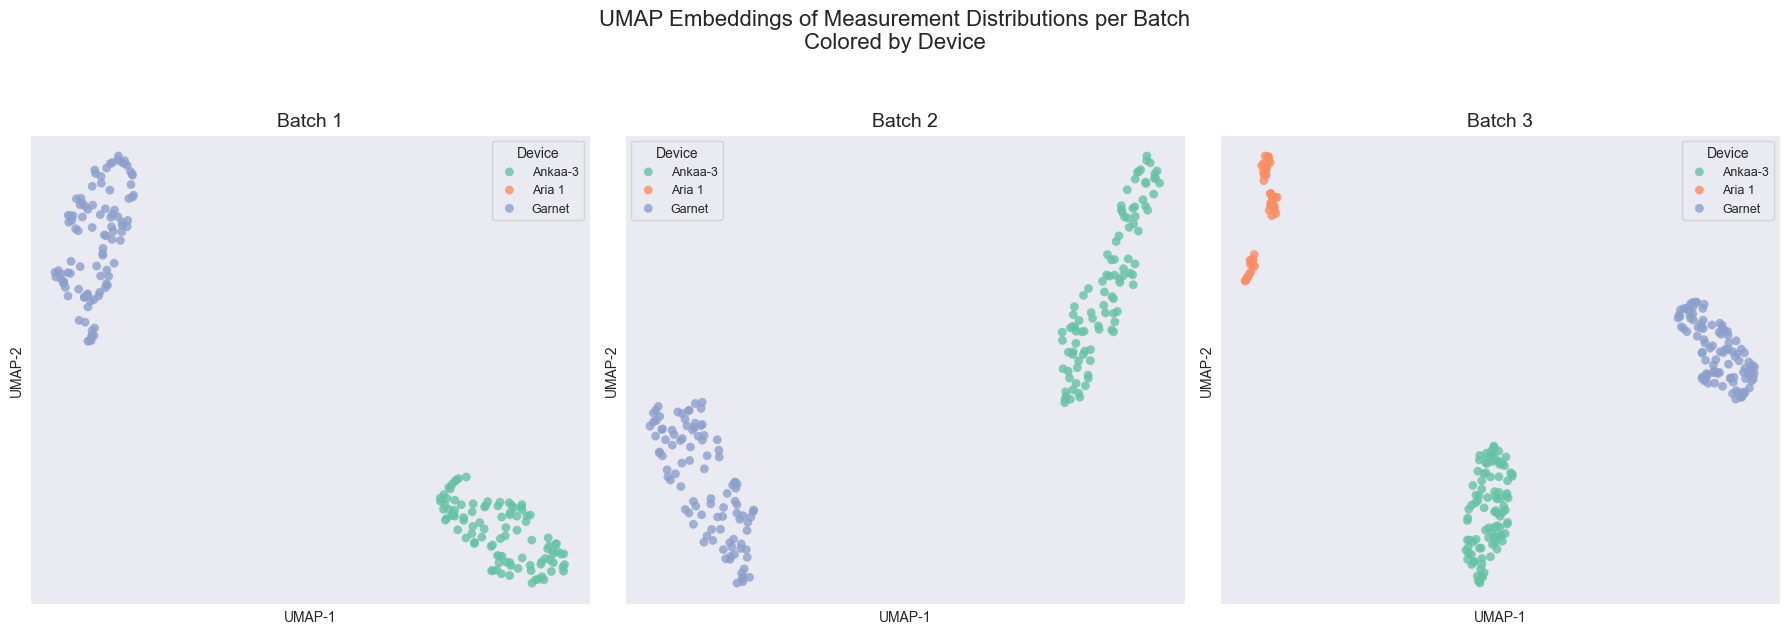

In [10]:
# Ensure datetime is parsed and sorted
data_df['completion_time'] = pd.to_datetime(data_df['completion_time'])
data_df = data_df.sort_values('completion_time')

# Identify probability columns and batches
prob_cols = [c for c in data_df.columns if c.startswith('x')]
batches = sorted(data_df['batch'].unique())
devices = sorted(data_df['device'].unique())

# Color palette for devices
palette = sns.color_palette("Set2", n_colors=len(devices))
device_colors = dict(zip(devices, palette))

# --- One UMAP per batch (3 subplots total) ---
fig, axes = plt.subplots(1, len(batches), figsize=(18, 6))
fig.suptitle("UMAP Embeddings of Measurement Distributions per Batch\nColored by Device", fontsize=16, y=1.05)

for j, batch in enumerate(batches):
    ax = axes[j]
    subset = data_df[data_df['batch'] == batch]
    
    if len(subset) < 2:
        ax.text(0.5, 0.5, 'Not enough data', ha='center', va='center', fontsize=10)
        ax.set_axis_off()
        continue
    
    # Fit UMAP on that batch
    reducer = umap.UMAP(random_state=42)
    embedding = reducer.fit_transform(subset[prob_cols])
    subset = subset.copy()
    subset['umap1'] = embedding[:, 0]
    subset['umap2'] = embedding[:, 1]
    
    # Scatter with categorical coloring by device
    for device in devices:
        dev_subset = subset[subset['device'] == device]
        ax.scatter(dev_subset['umap1'], dev_subset['umap2'],
                   label=device,
                   color=device_colors[device],
                   s=40, alpha=0.8, edgecolor='none')
    
    ax.set_title(f"Batch {batch}", fontsize=14)
    ax.set_xlabel("UMAP-1")
    ax.set_ylabel("UMAP-2")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(title='Device', loc='best', fontsize=9, title_fontsize=10)

plt.tight_layout()
plt.show()


# Entropy over time

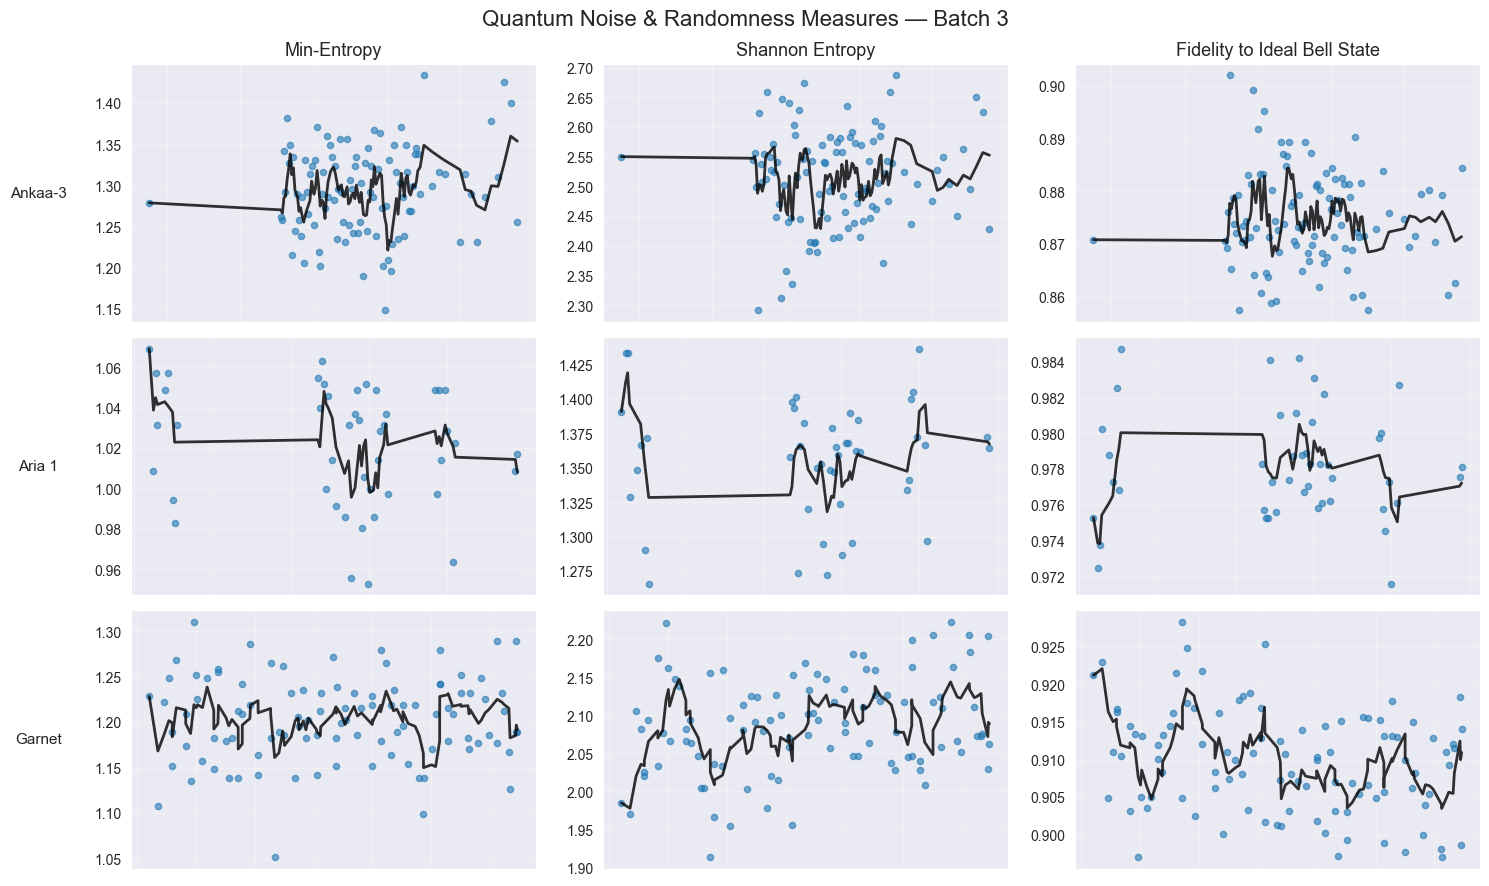

In [44]:
# --- Setup ---
# Ensure completion_time is datetime and sorted
data_df['completion_time'] = pd.to_datetime(data_df['completion_time'])
data_df = data_df.sort_values('completion_time')

# Filter for batch 3
batch_df = data_df[data_df['batch'] == 3].copy()

# Identify probability columns
prob_cols = [c for c in batch_df.columns if c.startswith('x')]

# Ideal Bell distribution (50% |00000>, 50% |11111>)
ideal_dist = np.zeros(len(prob_cols))
ideal_dist[prob_cols.index('x00000')] = 0.5
ideal_dist[prob_cols.index('x11111')] = 0.5

# --- Define measures ---
def min_entropy(p):
    p = np.asarray(p, dtype=float)
    p = p / np.sum(p)
    return -np.log2(np.max(p) + 1e-15)

def shannon_entropy(p):
    p = np.asarray(p, dtype=float)
    p = p / np.sum(p)
    p_nonzero = p[p > 0]
    return -np.sum(p_nonzero * np.log2(p_nonzero))

def fidelity(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = p / np.sum(p)
    q = q / np.sum(q)
    return np.sum(np.sqrt(p * q))

# --- Compute metrics ---
metrics = []
for device, dev_df in batch_df.groupby('device'):
    for _, row in dev_df.iterrows():
        p = row[prob_cols].to_numpy(dtype=float)
        metrics.append({
            'device': device,
            'completion_time': row['completion_time'],
            'min_entropy': min_entropy(p),
            'shannon_entropy': shannon_entropy(p),
            'fidelity_to_bell': fidelity(p, ideal_dist)
        })

metrics_df = pd.DataFrame(metrics)

# --- Parameters ---
rolling_window = 5  # number of points for rolling mean (adjustable)
devices = sorted(metrics_df['device'].unique())
metrics_list = ['min_entropy', 'shannon_entropy', 'fidelity_to_bell']
metric_titles = ['Min-Entropy', 'Shannon Entropy', 'Fidelity to Ideal Bell State']

# --- Plot ---
fig, axes = plt.subplots(len(devices), len(metrics_list), figsize=(15, 9))
fig.suptitle('Quantum Noise & Randomness Measures — Batch 3', fontsize=16, y=0.98)

for i, device in enumerate(devices):
    dev_df = metrics_df[metrics_df['device'] == device].sort_values('completion_time')
    for j, metric in enumerate(metrics_list):
        ax = axes[i, j]

        # Scatter points
        ax.scatter(dev_df['completion_time'], dev_df[metric], s=20, alpha=0.6)

        # Rolling mean (moving average)
        smoothed = dev_df[metric].rolling(window=rolling_window, min_periods=1).mean()
        ax.plot(dev_df['completion_time'], smoothed, color='black', lw=2, alpha=0.8)

        # Style
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('')
        ax.tick_params(axis='x', which='both', labelbottom=False)  # hide tick labels

        if i == 0:
            ax.set_title(metric_titles[j], fontsize=13)
        if j == 0:
            ax.set_ylabel(device, fontsize=11, rotation=0, labelpad=40, va='center')

plt.tight_layout()
plt.show()


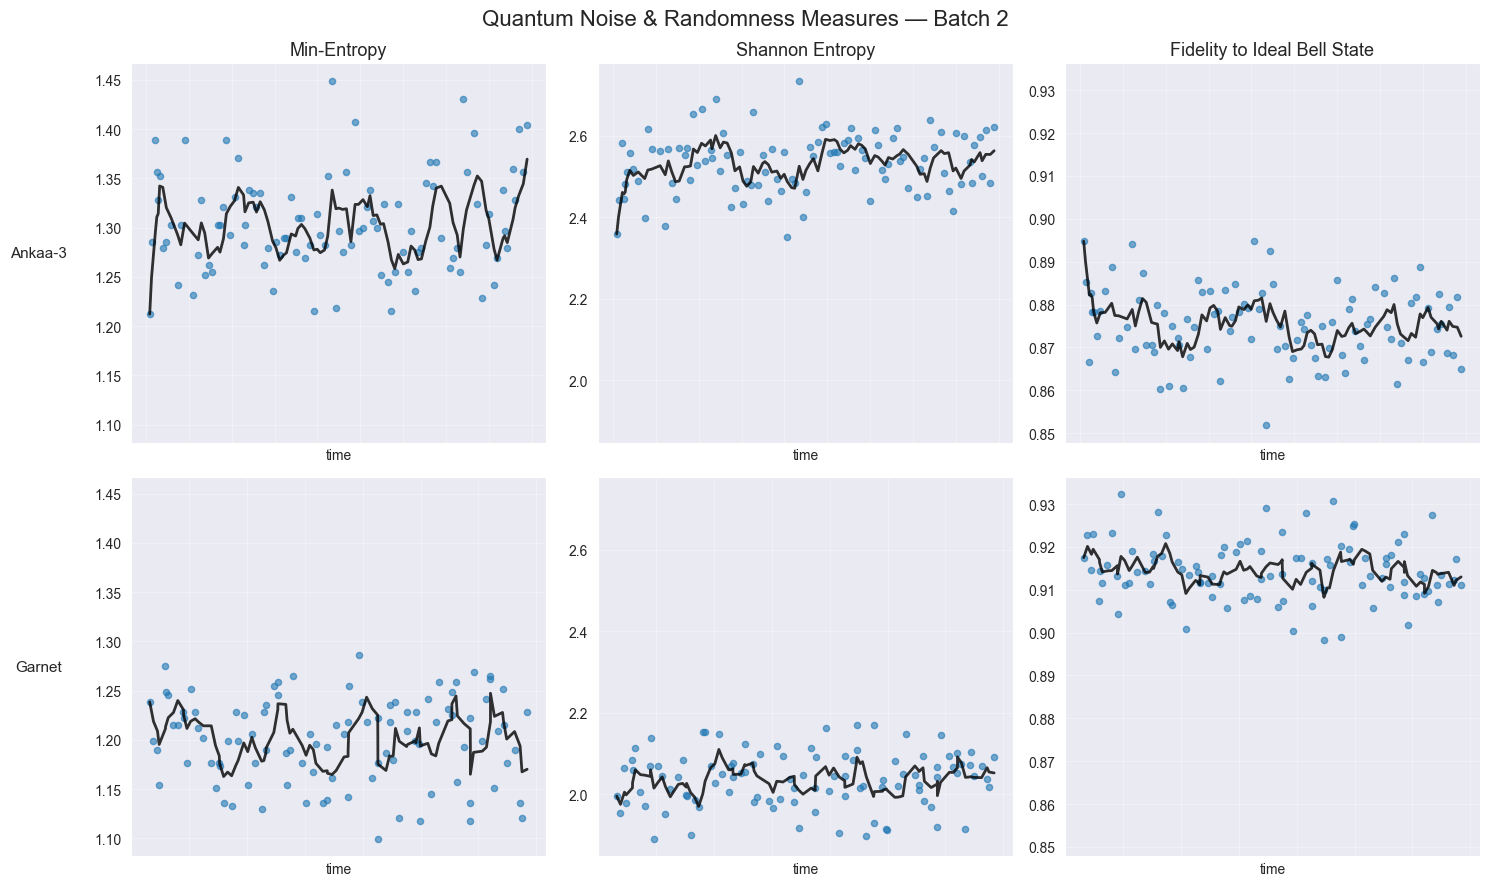

In [49]:
# --- Setup ---
# Ensure completion_time is datetime and sorted
data_df['completion_time'] = pd.to_datetime(data_df['completion_time'])
data_df = data_df.sort_values('completion_time')

# Filter for batch 3
batch_df = data_df[data_df['batch'] == 2].copy()

# Identify probability columns
prob_cols = [c for c in batch_df.columns if c.startswith('x')]

# Ideal Bell distribution (50% |00000>, 50% |11111>)
ideal_dist = np.zeros(len(prob_cols))
ideal_dist[prob_cols.index('x00000')] = 0.5
ideal_dist[prob_cols.index('x11111')] = 0.5

# --- Define measures ---
def min_entropy(p):
    p = np.asarray(p, dtype=float)
    p = p / np.sum(p)
    return -np.log2(np.max(p) + 1e-15)

def shannon_entropy(p):
    p = np.asarray(p, dtype=float)
    p = p / np.sum(p)
    p_nonzero = p[p > 0]
    return -np.sum(p_nonzero * np.log2(p_nonzero))

def fidelity(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = p / np.sum(p)
    q = q / np.sum(q)
    return np.sum(np.sqrt(p * q))

# --- Compute metrics ---
metrics = []
for device, dev_df in batch_df.groupby('device'):
    for _, row in dev_df.iterrows():
        p = row[prob_cols].to_numpy(dtype=float)
        metrics.append({
            'device': device,
            'completion_time': row['completion_time'],
            'min_entropy': min_entropy(p),
            'shannon_entropy': shannon_entropy(p),
            'fidelity_to_bell': fidelity(p, ideal_dist)
        })

metrics_df = pd.DataFrame(metrics)

# --- Parameters ---
rolling_window = 5  # number of points for rolling mean (adjustable)
devices = sorted(metrics_df['device'].unique())
metrics_list = ['min_entropy', 'shannon_entropy', 'fidelity_to_bell']
metric_titles = ['Min-Entropy', 'Shannon Entropy', 'Fidelity to Ideal Bell State']

# --- Plot ---
fig, axes = plt.subplots(len(devices), len(metrics_list), figsize=(15, 9), sharey='col')
fig.suptitle('Quantum Noise & Randomness Measures — Batch 2', fontsize=16, y=0.98)

for i, device in enumerate(devices):
    dev_df = metrics_df[metrics_df['device'] == device].sort_values('completion_time')
    for j, metric in enumerate(metrics_list):
        ax = axes[i, j]

        # Scatter points
        ax.scatter(dev_df['completion_time'], dev_df[metric], s=20, alpha=0.6)

        # Rolling mean (moving average)
        smoothed = dev_df[metric].rolling(window=rolling_window, min_periods=1).mean()
        ax.plot(dev_df['completion_time'], smoothed, color='black', lw=2, alpha=0.8)

        # Style
        ax.grid(True, alpha=0.3)
        ax.set_xlabel('time')
        ax.tick_params(axis='x', which='both', labelbottom=False)  # hide tick labels

        if i == 0:
            ax.set_title(metric_titles[j], fontsize=13)
        if j == 0:
            ax.set_ylabel(device, fontsize=11, rotation=0, labelpad=40, va='center')

plt.tight_layout()
plt.show()


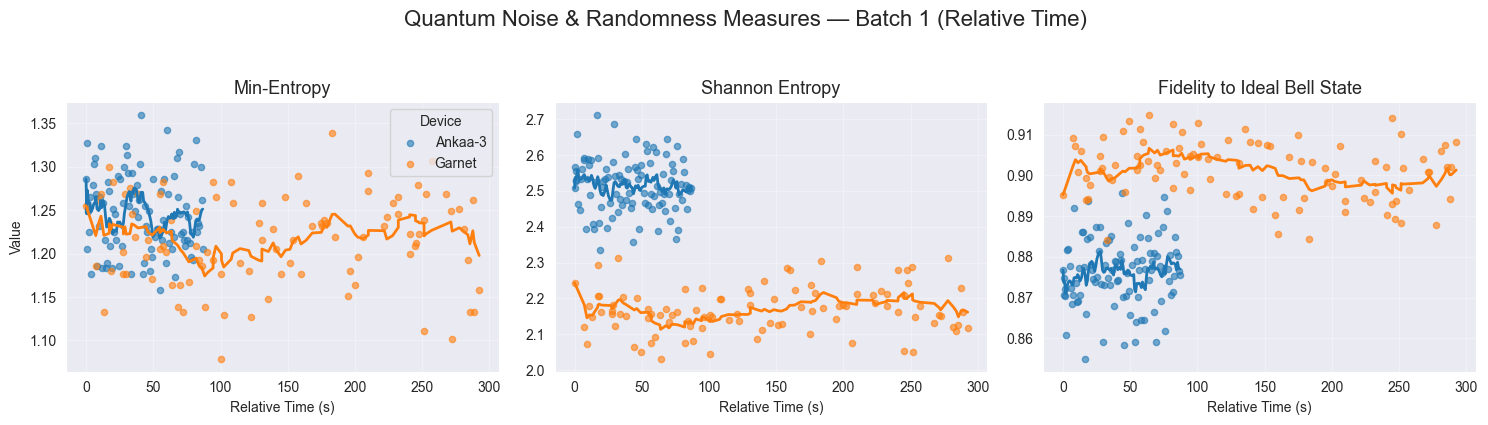

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# --- Setup ---
data_df['completion_time'] = pd.to_datetime(data_df['completion_time'])
data_df = data_df.sort_values('completion_time')

# Filter for batch 3
batch_df = data_df[data_df['batch'] == 1].copy()

# Identify probability columns
prob_cols = [c for c in batch_df.columns if c.startswith('x')]

# Ideal Bell distribution (|00000> and |11111> with equal probability)
ideal_dist = np.zeros(len(prob_cols))
ideal_dist[prob_cols.index('x00000')] = 0.5
ideal_dist[prob_cols.index('x11111')] = 0.5

# --- Metric definitions ---
def min_entropy(p):
    p = np.asarray(p, dtype=float)
    p = p / np.sum(p)
    return -np.log2(np.max(p) + 1e-15)

def shannon_entropy(p):
    p = np.asarray(p, dtype=float)
    p = p / np.sum(p)
    p_nonzero = p[p > 0]
    return -np.sum(p_nonzero * np.log2(p_nonzero))

def fidelity(p, q):
    p = np.asarray(p, dtype=float)
    q = np.asarray(q, dtype=float)
    p = p / np.sum(p)
    q = q / np.sum(q)
    return np.sum(np.sqrt(p * q))

# --- Compute metrics ---
metrics = []
for device, dev_df in batch_df.groupby('device'):
    first_time = dev_df['completion_time'].min()
    for _, row in dev_df.iterrows():
        p = row[prob_cols].to_numpy(dtype=float)
        rel_time = (row['completion_time'] - first_time).total_seconds()
        metrics.append({
            'device': device,
            'relative_time_sec': rel_time,
            'min_entropy': min_entropy(p),
            'shannon_entropy': shannon_entropy(p),
            'fidelity_to_bell': fidelity(p, ideal_dist)
        })

metrics_df = pd.DataFrame(metrics)

# --- Plot parameters ---
rolling_window = 10  # number of points for rolling mean
devices = sorted(metrics_df['device'].unique())
colors = ['tab:blue', 'tab:orange']
metrics_list = ['min_entropy', 'shannon_entropy', 'fidelity_to_bell']
metric_titles = ['Min-Entropy', 'Shannon Entropy', 'Fidelity to Ideal Bell State']

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Quantum Noise & Randomness Measures — Batch 1 (Relative Time)', fontsize=16, y=1.05)

for j, (metric, title) in enumerate(zip(metrics_list, metric_titles)):
    ax = axes[j]
    for color, device in zip(colors, devices):
        dev_df = metrics_df[metrics_df['device'] == device].sort_values('relative_time_sec')

        # Scatter plot
        ax.scatter(dev_df['relative_time_sec'], dev_df[metric], s=20, alpha=0.6, color=color, label=device)

        # Rolling mean (using sample index window, not time window)
        smoothed = dev_df[metric].rolling(window=rolling_window, min_periods=1).mean()
        ax.plot(dev_df['relative_time_sec'], smoothed, color=color, lw=2)

    ax.set_title(title, fontsize=13)
    ax.grid(True, alpha=0.3)
    ax.tick_params(axis='x', labelbottom=True)
    ax.set_xlabel('Relative Time (s)')
    if j == 0:
        ax.set_ylabel('Value')
    else:
        ax.set_ylabel('')

axes[0].legend(title='Device')
plt.tight_layout()
plt.show()
